In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dileep070/heart-disease-prediction-using-logistic-regression/framingham.csv


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels.stats.proportion as smp
from sklearn.metrics import roc_auc_score, roc_curve

# Import the dataset

In [4]:
my_filepath = "/kaggle/input/datasets/dileep070/heart-disease-prediction-using-logistic-regression/framingham.csv"

#csv to dataframe
data = pd.read_csv(my_filepath)

## Description of the variables

The dataset provides patients’ information. It includes over 4,000 records and 15 attributes.  
Each attribute is a potential risk factor. There are both demographic, behavioral and medical risk factors.

Demographic:  
• **Sex**: male or female(Nominal)  
• **Age**: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

Behavioral:  
• **Current Smoker**: whether or not the patient is a current smoker (Nominal)  
• **Cigs Per Day**: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)

Medical history:  
• **BP Meds**: whether or not the patient was on blood pressure medication (Nominal)  
• **Prevalent Stroke**: whether or not the patient had previously had a stroke (Nominal)  
• **Prevalent Hyp**: whether or not the patient was hypertensive (Nominal)  
•**Diabetes**: whether or not the patient had diabetes (Nominal)  

Medical(current):  
• **Tot Chol**: total cholesterol level (Continuous)  
• **Sys BP**: systolic blood pressure (Continuous)  
• **Dia BP**: diastolic blood pressure (Continuous)  
• **BMI**: Body Mass Index (Continuous)  
• **Heart Rate**: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)  
• **Glucose**: glucose level (Continuous)

Predict variable (desired target)  
• **TenYearCHD**: 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)

# Data Overview and pre-treatment

In [5]:
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
data.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [7]:
data.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [8]:
smoker_na=data[data["currentSmoker"]==1]["cigsPerDay"].isna().sum()
perc_smoker_na=smoker_na/len(data[data["currentSmoker"]==1]["cigsPerDay"])*100
print(f"""
There are {smoker_na} missing values on cigsPerDay among current smokers.
It represents {perc_smoker_na:.1f}% of current smokers values.
""")


There are 29 missing values on cigsPerDay among current smokers.
It represents 1.4% of current smokers values.



In [9]:
perc_missing_values=((len(data)-data.count())/len(data)*100).round(1)
nan_rows=len(data)-len(data.dropna())
print(f"""
The percentage of missing values :
{perc_missing_values}
The total number of rows with nan : {nan_rows}, representing {nan_rows/len(data)*100:.0f}% of total rows
""")


The percentage of missing values :
male               0.0
age                0.0
education          2.5
currentSmoker      0.0
cigsPerDay         0.7
BPMeds             1.3
prevalentStroke    0.0
prevalentHyp       0.0
diabetes           0.0
totChol            1.2
sysBP              0.0
diaBP              0.0
BMI                0.4
heartRate          0.0
glucose            9.2
TenYearCHD         0.0
dtype: float64
The total number of rows with nan : 582, representing 14% of total rows



I don't want to keep na in the rows for the logistic regression. As the nan rows represents a low percentage of the dataset, I sill have sufficient rows to fit a stable logistic regression model. Another way to deal with the missing values is to fill them with the mean or median.

In [10]:
duplicates=data.duplicated().sum()
print(f"""
There are {duplicates} duplicates.
""")


There are 0 duplicates.



In [11]:
data_clean=data.dropna()

# Explorationay Data Analysis

<Axes: xlabel='TenYearCHD', ylabel='count'>

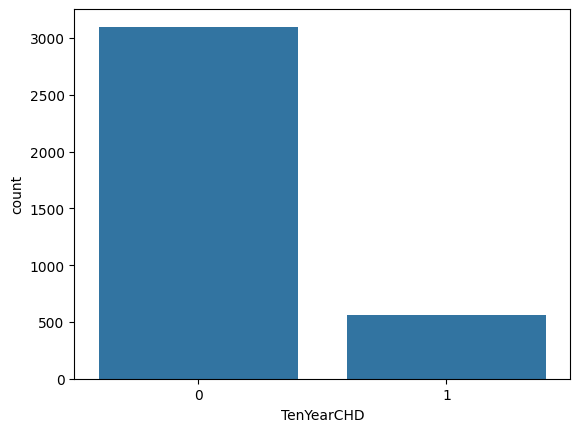

In [12]:
sns.countplot(data_clean,x=data_clean['TenYearCHD'])

Most patients of the cohort don't have any 10-year risk of coronary heart disease CHD.

# Logistic regression

### Collinearity identification

With so many variables in the dataset, let's first check pairwise correlation.

High correlation pairs (> 0.6):
cigsPerDay <--> currentSmoker: 0.77
diaBP <--> prevalentHyp: 0.62
prevalentHyp <--> sysBP: 0.70
diaBP <--> sysBP: 0.79
diabetes <--> glucose: 0.61


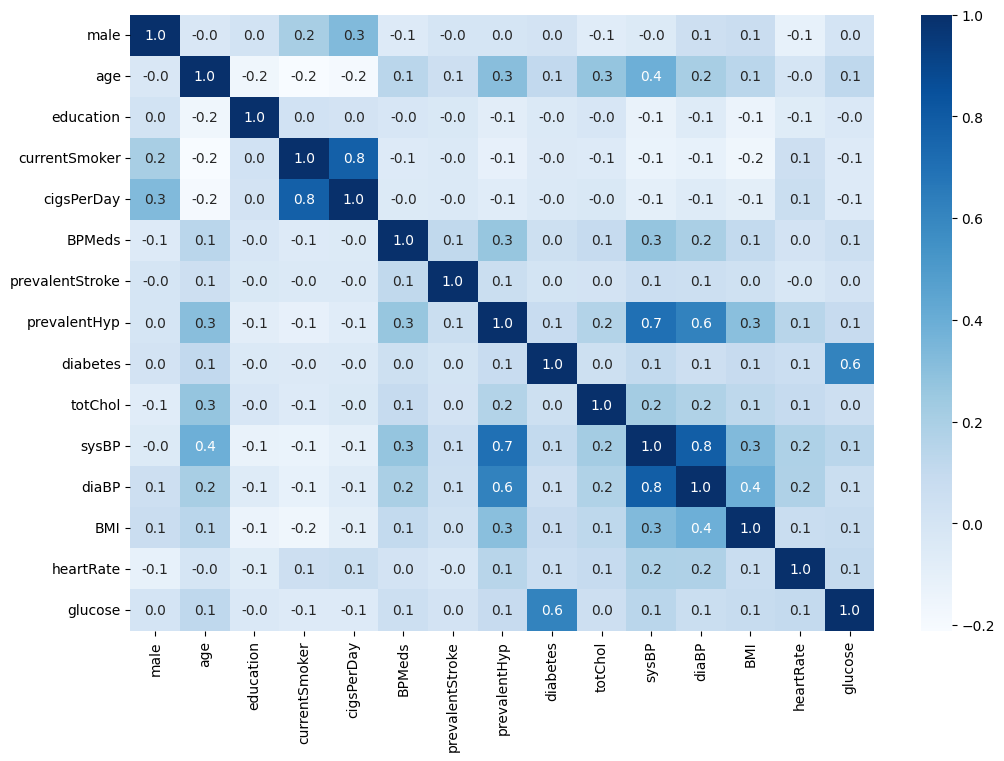

In [13]:
x=data_clean.drop(columns=['TenYearCHD']) #contains all predictor variables excluding Y
y=data_clean['TenYearCHD']
corr_matrix=x.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap="Blues",fmt='.1f')
print("High correlation pairs (> 0.6):")
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if row != col and abs(corr_matrix.loc[row, col]) > 0.6 and row < col:
            print(f"{row} <--> {col}: {corr_matrix.loc[row, col]:.2f}")

The multicollinearity makes sense with clinical domain knowledge. The next step is to selectively drop redundant features :
- drop `currentSmoker` as it contains less information than `cigsPerDay` (this is a continuous variable + non-smokers are represented by 0)
- drop `prevalentHyp` as this feature is determined by blood pressure values (`sysBP` and `diaBP`)
- keep `diabetes` and `glucose` : even though these variables are correlated, diabete brings a additionnal information of chronic situation (while glucose measurement may be subject to temporary patient fluctuation). 

### Backward elimination

In [14]:
X=data_clean.drop(columns=['TenYearCHD',"currentSmoker","prevalentHyp"]) #contains all predictor variables excluding Y and the collinear variables identified above
y=data_clean['TenYearCHD']

# Explicitly add intercept term (column of 1s)
x_with_const = sm.add_constant(x)

model = sm.Logit(y,x_with_const)
result=model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.376668
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             TenYearCHD   No. Observations:                 3656
Model:                          Logit   Df Residuals:                     3640
Method:                           MLE   Df Model:                           15
Date:                Fri, 09 Oct 2026   Pseudo R-squ.:                  0.1174
Time:                        06:31:44   Log-Likelihood:                -1377.1
converged:                       True   LL-Null:                       -1560.3
Covariance Type:            nonrobust   LLR p-value:                 8.027e-69
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -8.3222      0.715    -11.632      0.000      -9.725      -6.920
male                0.5551      0.109      5.090      0.000       0.341       0.769
age                 0.0635      0.007      9.499      0.000       0.050       0.077
education          -0.0475      0.049     -0.962      0.336      -0.144       0.049
currentSmoker       0.0709      0.157      0.452      0.651      -0.236       0.378
cigsPerDay          0.0179      0.006      2.874      0.004       0.006       0.030
BPMeds              0.1623      0.234      0.692      0.489      -0.297       0.621
prevalentStroke     0.6935      0.490      1.417      0.157      -0.266       1.653
prevalentHyp        0.2346      0.138      1.700      0.089      -0.036       0.505
diabetes            0.0395      0.315      0.125      0.900      -0.579       0.658
totChol             0.0023      0.001      2.062      0.039       0.000       0.005
sysBP               0.0154      0.004      4.043      0.000       0.008       0.023
diaBP              -0.0041      0.006     -0.642      0.521      -0.017       0.008
BMI                 0.0066      0.013      0.518      0.605      -0.018       0.032
heartRate          -0.0032      0.004     -0.772      0.440      -0.012       0.005
glucose             0.0071      0.002      3.189      0.001       0.003       0.012
===================================================================================
"""

### Using AIC

In [15]:
# It test removing every single remaining variable independently and only drops the one that reduces the AIC the most.
def backward_elimination_aic(X, y):
    current_features = list(X.columns)
    best_aic = sm.Logit(y, sm.add_constant(X[current_features])).fit(disp=False).aic
    
    while len(current_features) > 1:
        worst_feature = None
        #loop iterates through all active features in the list, temporarily dropping each one one-by-one to calculate its specific impact on model AIC.
        for feature in current_features: 
            features_to_test = [f for f in current_features if f != feature]
            model = sm.Logit(y, sm.add_constant(X[features_to_test])).fit(disp=False)
            if model.aic < best_aic:
                best_aic = model.aic
                worst_feature = feature
                
        if worst_feature is not None:
            current_features.remove(worst_feature)
            print(f"Removed '{worst_feature}' -> New AIC: {round(best_aic, 2)}")
        else:
            break
            
    return current_features


selected_features_aic = backward_elimination_aic(X, y)
print("\n Selected features by AIC:", selected_features_aic)

Removed 'diabetes' -> New AIC: 2783.28
Removed 'diaBP' -> New AIC: 2781.47
Removed 'BMI' -> New AIC: 2779.73
Removed 'heartRate' -> New AIC: 2778.2
Removed 'BPMeds' -> New AIC: 2776.98
Removed 'education' -> New AIC: 2775.98

 Selected features by AIC: ['male', 'age', 'cigsPerDay', 'prevalentStroke', 'totChol', 'sysBP', 'glucose']


### Using P-value

In [16]:
def backward_elimination_pvalue(X, y, threshold=0.05):
    current_features = list(X.columns)
    
    while True:
        # Fit model with current features + intercept
        X_const = sm.add_constant(X[current_features])
        model = sm.Logit(y, X_const).fit(disp=False)
        
        # Get p-values (excluding the intercept 'const')
        p_values = model.pvalues.drop('const')
        max_p = p_values.max()
        
        # If the highest p-value exceeds our threshold, remove that feature
        if max_p > threshold:
            worst_feature = p_values.idxmax()
            current_features.remove(worst_feature)
            print(f"Removed '{worst_feature}' (p-value: {max_p:.4f})")
        else:
            break
            
    return current_features

selected_features_p = backward_elimination_pvalue(X, y, threshold=0.05)
print("\n Selected features by P-value:", selected_features_p)

Removed 'diabetes' (p-value: 0.8842)
Removed 'diaBP' (p-value: 0.6700)
Removed 'BMI' (p-value: 0.6068)
Removed 'heartRate' (p-value: 0.4929)
Removed 'BPMeds' (p-value: 0.3747)
Removed 'education' (p-value: 0.3183)
Removed 'prevalentStroke' (p-value: 0.1037)

 Selected features by P-value: ['male', 'age', 'cigsPerDay', 'totChol', 'sysBP', 'glucose']


In [17]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline: Scales data first, then applies Logistic Regression with L1 (Lasso) penalty
# Note: 'liblinear' or 'saga' solvers support L1 penalty in scikit-learn
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegressionCV(
        Cs=10, 
        cv=5, 
        penalty='l1', 
        solver='saga', 
        scoring='roc_auc', 
        max_iter=1000,
        random_state=42
    ))
])

# Fit model
lasso_pipeline.fit(X, y)

# Inspect selected features (non-zero coefficients)
model = lasso_pipeline.named_steps['clf']
feature_mask = model.coef_[0] != 0
selected_features_l = X.columns[feature_mask]

print("Selected features by Lasso:", list(selected_features_l))

Selected features by Lasso: ['male', 'age', 'education', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'totChol', 'sysBP', 'glucose']


In [18]:
print(f"""
Selected features by AIC: {selected_features_aic}
Selected features by P-value: {selected_features_p}
Selected features by Lasso:", {list(selected_features_l)}
""")


Selected features by AIC: ['male', 'age', 'cigsPerDay', 'prevalentStroke', 'totChol', 'sysBP', 'glucose']
Selected features by P-value: ['male', 'age', 'cigsPerDay', 'totChol', 'sysBP', 'glucose']
Selected features by Lasso:", ['male', 'age', 'education', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'totChol', 'sysBP', 'glucose']



The Lasso method is more inclusive. I will keep the core 6 variables that are selected by all three methods : 'male', 'age', 'cigsPerDay', 'totChol', 'sysBP', 'glucose'.

## Fitting a Logistic regression

In [19]:
X=data_clean[selected_features_p] #contains all predictor variables excluding Y and the collinear variables identified above
y=data_clean['TenYearCHD']

# Explicitly add intercept term (column of 1s)
x_with_const = sm.add_constant(X)

model = sm.Logit(y,x_with_const)
result=model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.377800
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             TenYearCHD   No. Observations:                 3656
Model:                          Logit   Df Residuals:                     3649
Method:                           MLE   Df Model:                            6
Date:                Fri, 09 Oct 2026   Pseudo R-squ.:                  0.1147
Time:                        06:31:46   Log-Likelihood:                -1381.2
converged:                       True   LL-Null:                       -1560.3
Covariance Type:            nonrobust   LLR p-value:                 2.885e-74
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.1298      0.476    -19.199      0.000     -10.062      -8.198
male           0.5614      0.107      5.255      0.000       0.352       0.771
age            0.0659      0.006     10.254      0.000       0.053       0.078
cigsPerDay     0.0192      0.004      4.604      0.000       0.011       0.027
totChol        0.0023      0.001      2.024      0.043    7.16e-05       0.004
sysBP          0.0175      0.002      8.159      0.000       0.013       0.022
glucose        0.0073      0.002      4.342      0.000       0.004       0.011
==============================================================================
"""

Positive coefficients mean that an increase in those variables is associated with higher heart disease risk.  
Let's compute odds for each variable. For sex, female is the baseline so the coefficient for male represent the increase in odds for male compared to female after holding all other variables constant.
$$\frac{\text{Odds}_{\text{male}}}{\text{Odds}_{\text{female}}} = e^{\beta_{\text{male}}}$$

### Scaling for larger clinically meaningful steps

In [20]:
params=result.params
CI=result.conf_int()
OR_CI=pd.DataFrame({
    'Odds_Ratio_one':np.exp(params), #for 1 unit
    'Lower_CI_one':np.exp(CI[0]),
    'Upper_CI_one':np.exp(CI[1])
})
print(OR_CI)

            Odds_Ratio_one  Lower_CI_one  Upper_CI_one
const             0.000108      0.000043      0.000275
male              1.753206      1.421955      2.161623
age               1.068116      1.054747      1.081654
cigsPerDay        1.019412      1.011102      1.027789
totChol           1.002275      1.000072      1.004483
sysBP             1.017689      1.013411      1.021985
glucose           1.007307      1.004002      1.010623


I want to scale up the value in order to provide more relevant interpretation. I need to do a bit of research to identify the range of possible values for the variable in order to determine clinically meaningful step.

`totChol`: At risk cholesterol levels are from 200mg/dL. Below is heart healthy. Let's take a 50 level step.  

`cigsPerDay`: A packet of cigarettes contains about 20 cigarettes.  

`sysBP`: The systolic blood pressure is Normal : <120, Elevated:[120;129], High Blood1=[130;139], High Blood2=[>140] and Hypertensive crisis=>180
So taking a 10mm Hg step seems clinically relevant.

`glucose`: Glucose level is normal= <100mg/dL, 100-125mg/dl falls under the catgeory of prediabetes. >126mg/dL type 2 diabetes.
So taking a 10mg/dL step seems clinically relevant.

Of course, the values chosen here are approximate and are based on common sense derived from quick internet searches. Seeking clinical expertise would yield more relevant and representative values.

In [21]:
OR_CI['OR_one_perc']=(OR_CI['Odds_Ratio_one']-1)*100
OR_CI['lowCI_one_perc']=(OR_CI['Lower_CI_one']-1)*100
OR_CI['upperCI_one_perc']=(OR_CI['Upper_CI_one']-1)*100

age_scale=10 #years
cigsPerDay_scale=20 #number of cigarettes = 1 packet
totChol_scale=50 #mg/dL
sysBP_scale=10 #mm Hg
glucose_scale=10 #mg/dL

scaled_values=[1,1,age_scale,cigsPerDay_scale,totChol_scale,sysBP_scale,glucose_scale]
OR_CI['scaled_values']=scaled_values

OR_CI['Odds_Ratio_scaled']=OR_CI["Odds_Ratio_one"]**OR_CI['scaled_values']
OR_CI['Lower_CI_scaled']=OR_CI["Lower_CI_one"]**OR_CI['scaled_values']
OR_CI['Upper_CI_scaled']=OR_CI["Upper_CI_one"]**OR_CI['scaled_values']

OR_CI['OR_scaled_perc']=(OR_CI['Odds_Ratio_scaled']-1)*100
OR_CI['lowCI_scaled_perc']=(OR_CI['Lower_CI_scaled']-1)*100
OR_CI['upperCI_scaled_perc']=(OR_CI['Upper_CI_scaled']-1)*100

OR_CI

,Odds_Ratio_one,Lower_CI_one,Upper_CI_one,OR_one_perc,lowCI_one_perc,upperCI_one_perc,scaled_values,Odds_Ratio_scaled,Lower_CI_scaled,Upper_CI_scaled,OR_scaled_perc,lowCI_scaled_perc,upperCI_scaled_perc
const,0.000108,0.000043,0.000275,-99.989162,-99.995732,-99.972475,1,0.000108,0.000043,0.000275,-99.989162,-99.995732,-99.972475
male,1.753206,1.421955,2.161623,75.320585,42.195539,116.162250,1,1.753206,1.421955,2.161623,75.320585,42.195539,116.162250
age,1.068116,1.054747,1.081654,6.811610,5.474737,8.165428,10,1.932790,1.704059,2.192223,93.278976,70.405853,119.222297
cigsPerDay,1.019412,1.011102,1.027789,1.941152,1.110243,2.778889,20,1.468895,1.247105,1.730129,46.889496,24.710514,73.012870
totChol,1.002275,1.000072,1.004483,0.227468,0.007156,0.448266,50,1.120309,1.003584,1.250611,12.030947,0.358424,25.061082
sysBP,1.017689,1.013411,1.021985,1.768897,1.341125,2.198474,10,1.191655,1.142503,1.242923,19.165533,14.250267,24.292263
glucose,1.007307,1.004002,1.010623,0.730684,0.400184,1.062272,10,1.075518,1.040747,1.111452,7.551836,4.074680,11.145165


### Results

In [30]:
print(f"""
Holding other features constant (or under the same conditions): 
men have {OR_CI.loc['male','OR_scaled_perc']:.0f}% higher odds of heart disease than women (CI95%:[{OR_CI.loc['male','lowCI_scaled_perc']:.0f}%;{OR_CI.loc['male','upperCI_scaled_perc']:.0f}%]).  
For a {OR_CI.loc['age','scaled_values']}-year increase in age, the odds of having a heart disease are higher by {OR_CI.loc['age','OR_scaled_perc']:.0f}% (CI95%:[{OR_CI.loc['age','lowCI_scaled_perc']:.0f}%;{OR_CI.loc['age','upperCI_scaled_perc']:.0f}%])
For an increase of 1 pack of cigarettes per day, the odds of having a heart disease are higher by {OR_CI.loc['cigsPerDay','OR_scaled_perc']:.0f}% (CI95%:[{OR_CI.loc['cigsPerDay','lowCI_scaled_perc']:.0f}%;{OR_CI.loc['cigsPerDay','upperCI_scaled_perc']:.0f}%])
For a {OR_CI.loc['totChol','scaled_values']}-mg/dL increase in total cholesterol, the odds of having a heart disease are higher by {OR_CI.loc['totChol','OR_scaled_perc']:.0f}% (CI95%:[{OR_CI.loc['totChol','lowCI_scaled_perc']:.0f}%;{OR_CI.loc['totChol','upperCI_scaled_perc']:.0f}%])
For a {OR_CI.loc['sysBP','scaled_values']}-mm Hg increase in systolic blood pressure, the odds of having a heart disease are higher by {OR_CI.loc['sysBP','OR_scaled_perc']:.0f}% (CI95%:[{OR_CI.loc['sysBP','lowCI_scaled_perc']:.0f}%;{OR_CI.loc['sysBP','upperCI_scaled_perc']:.0f}%])
For a {OR_CI.loc['glucose','scaled_values']}-mg/dL increase in glucose level, the odds of having a heart disease are higher by {OR_CI.loc['glucose','OR_scaled_perc']:.0f}% (CI95%:[{OR_CI.loc['glucose','lowCI_scaled_perc']:.0f}%;{OR_CI.loc['glucose','upperCI_scaled_perc']:.0f}%])

In other words, if we take the `cigsPerday` variable:   
if we compare two otherwise identical men (same age, same cholesterol, same blood pressure etc.) smoking 1 pack of cigarettes difference, the man who smokes 1 additional pack per day has odds of heart disease higher by {OR_CI.loc['cigsPerDay','OR_scaled_perc']:.0f}% compared to the other man.
""")


Holding other features constant (or under the same conditions): 
men have 75% higher odds of heart disease than women (CI95%:[42%;116%]).  
For a 10-year increase in age, the odds of having a heart disease are higher by 93% (CI95%:[70%;119%])
For an increase of 1 pack of cigarettes per day, the odds of having a heart disease are higher by 47% (CI95%:[25%;73%])
For a 50-mg/dL increase in total cholesterol, the odds of having a heart disease are higher by 12% (CI95%:[0%;25%])
For a 10-mm Hg increase in systolic blood pressure, the odds of having a heart disease are higher by 19% (CI95%:[14%;24%])
For a 10-mg/dL increase in glucose level, the odds of having a heart disease are higher by 8% (CI95%:[4%;11%])

In other words, if we take the `cigsPerday` variable:   
if we compare two otherwise identical men (same age, same cholesterol, same blood pressure etc.) smoking 1 pack of cigarettes difference, the man who smokes 1 additional pack per day has odds of heart disease higher by 47% compa

## Assess the quality of the model 

### calibration analysis

I calculate the calibration curve to check the reliability of the predicted probabilities ; to check if predicted probabilities match real observed frequencies.

I use a quantile-based binning rather than Equal Widths : with equal-width intervals (e.g., 0-10%, 10-20%, etc.), I would have the lower bins containing almost all the patients and higher bins would be empty. Quantiles ensure every bin has enough data to calculate a reliable observed average and confidence interval.

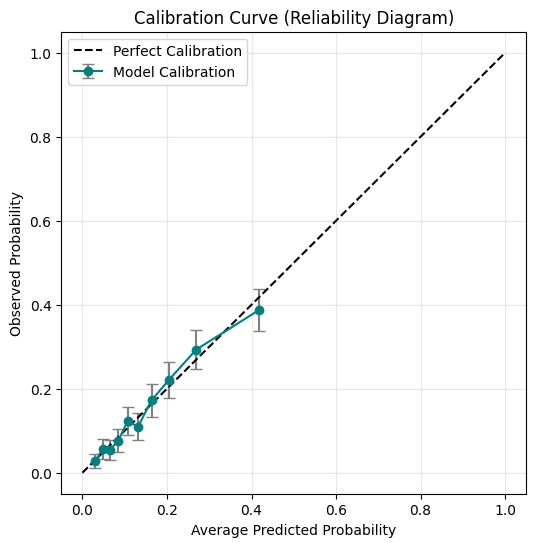

In [23]:
# 1. Create a DataFrame with true outcomes and model predicted probabilities
df_cal = pd.DataFrame({
    'y_true': y,
    'y_prob': result.predict(x_with_const) # statsmodels prediction
})

# 2. Bucket data into 10 groups based on predicted probabilities
df_cal['bin'] = pd.qcut(df_cal['y_prob'], q=10, duplicates='drop') #quantile-based binning
# attributes for each row a bin

# 3. Compute average predicted probability, observed probability, and count per bin
cal_summary = df_cal.groupby('bin', observed=True).agg(
    mean_pred=('y_prob', 'mean'),
    obs_prob=('y_true', 'mean'),
    n=('y_true', 'count'), #total observations in the bin
    successes=('y_true','sum') #total actual heat diseases cases in the bin
).reset_index()

# 4. Compute 95% Confidence Intervals for the observed probability (Normal approximation)
cal_summary['ci_lower'], cal_summary['ci_upper'] = smp.proportion_confint(
    count=cal_summary['successes'], # Number of positive cases (successes)
    nobs=cal_summary['n'], # Total count per bin
    alpha=0.05, # 95% confidence level
    method='normal' # Uses the normal approximation (z = 1.96)
)

# 5. Plotting
plt.figure(figsize=(6, 6))
plt.errorbar(
    cal_summary['mean_pred'], 
    cal_summary['obs_prob'], 
    yerr=[cal_summary['obs_prob'] - cal_summary['ci_lower'], 
          cal_summary['ci_upper'] - cal_summary['obs_prob']],
    fmt='o-', color='teal', ecolor='gray', capsize=4, label='Model Calibration'
)
# Perfect calibration reference line
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

plt.xlabel('Average Predicted Probability')
plt.ylabel('Observed Probability')
plt.title('Calibration Curve (Reliability Diagram)')
plt.ylim(-0.05, 1.05)
plt.xlim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

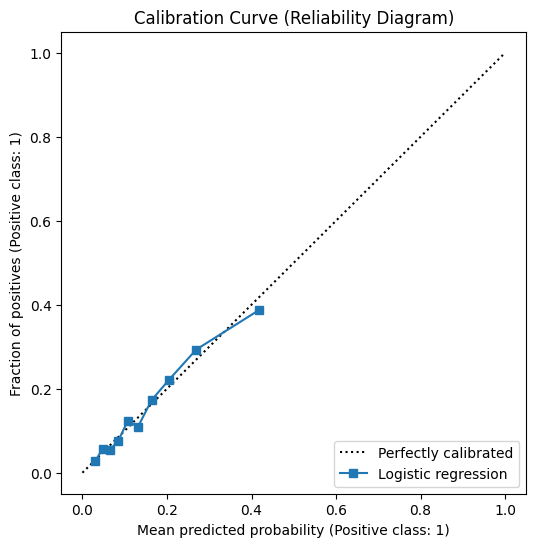

In [32]:
#version with CalibrationDisplay from sklearn. It has the downside of not plotting the confidence intervals for each bin. 
from sklearn.calibration import CalibrationDisplay

y_prob=result.predict(x_with_const)
y_true=y

fig, ax = plt.subplots(figsize=(6, 6))
display=CalibrationDisplay.from_predictions(
    y_true=y_true, 
    y_prob=y_prob, 
    n_bins=10, 
    strategy='quantile', # Can be 'uniform' or 'quantile'
    name='Logistic regression',
    ax=ax
)

plt.title('Calibration Curve (Reliability Diagram)')
plt.show()

The 95% confidence intervals of each of the buckets suggest that the logistic fit is reasonable for low probability patients and high probability patients.

### ROC-AUC score

ROC-AUC (Receiver Operating Characteristic - Area Under Curve) measures discrimination, that is to say, the model's ability to rank patients who get heart disease higher than those who do not, across all possible classification thresholds (it summarizes all of the confusion matrices that each threshold produced).
If ROC-AUC=0.5, it means the model performs no better than random guessing. 1 represents perfect discrimination.

ROC-AUC Score: 0.736


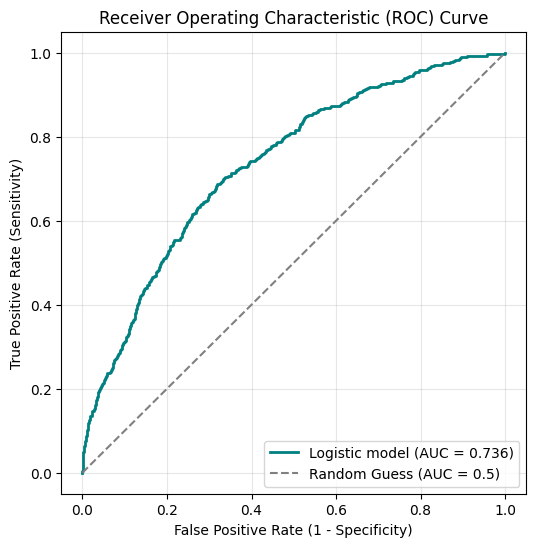

In [34]:
# 1. Calculate the ROC-AUC score
auc_score = roc_auc_score(y_true, y_prob)
print(f"ROC-AUC Score: {auc_score:.3f}")

# 2. Plot the full ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='teal', lw=2, label=f'Logistic model (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

True Positive Rate (Sensitivity): The proportion of actual heart disease cases correctly identified by the model.  
False Positive Rate (1 - Specificity): The proportion of healthy individuals incorrectly flagged as high risk.

The model achieves high sensitivity while maintaining low false positive rate.